# 5.0 Cosmos Reason 2 — End-to-end VLM Compression

In this notebook you will run the **complete compression pipeline** — prune → distill → quantize → serve → evaluate — on NVIDIA's [`nvidia/Cosmos-Reason2-2B`](https://huggingface.co/nvidia/Cosmos-Reason2-2B), a reasoning-specialised Vision-Language Model.

Notebooks [01](01_pruning_vlm.ipynb), [02](02_distillation_vlm.ipynb), [03](03_quantization_vlm.ipynb), [04](04_serving_and_eval_vlm.ipynb) walk through each stage individually on Qwen3-VL-8B-Instruct. **This notebook condenses all of them into one end-to-end run on a different model and shows quality recovery.** The Megatron-Bridge wrappers transfer across VLM families without code changes.

**Recovery target.** The compressed checkpoint at the end (pruned LM 1.4 B + distilled + FP8 — full VLM ~1.7 B) should land within a couple of points of the BF16 baseline on MathVista and on Cosmos's own Physical AI Bench domain, while not regressing on a general benchmark (RealWorldQA). §6 sets up a 4-way comparison so you can read off `% recovered` for each benchmark. The 15 % cut is on the LM tower (1.7 B → 1.4 B); the vision encoder + projector (0.3 B) is untouched, so the full VLM goes 2.0 B → ~1.7 B. The cut is intentionally conservative — the goal here is *full* recovery; aggressive compression (1.0–1.2 B LM) is a follow-on.

Pipeline overview (numbers assume **1 node, 8×H100**):

| Stage | What it does | Wall-time (approx.) |
|---|---|---|
| §1 Download | Pull the gated HF checkpoint (Cosmos-Reason2-2B, ~5 GB; LM tower 1.7 B + vision 0.3 B) | 5 min |
| §2 Prune (NAS) | Minitron NAS on the LM tower, target 1.4 B (15 % cut) | 15-25 min |
| §3 Distill | Text-only KD on the pruned LM tower, ~5 k iters | 8-14 h |
| §4 Quantize | FP8 PTQ with image-aware calibration | 10-15 min |
| §5 Serve | vLLM OpenAI-compatible endpoint | <2 min to spin up |
| §6 Evaluate | 4-way comparison × MathVista / PAI-Bench / RealWorldQA | 2-3 h |

> 🔐 Cosmos Reason 2 is **gated** on HuggingFace. Before running §1 request access at the model page and authenticate: `hf auth login --token <YOUR_HF_TOKEN>`.

> 🖥️ §3 (distillation) is the only stage that needs the full 8-GPU node. §2/§4/§5 each run on 1×H100; §6 reuses one GPU for the vLLM endpoint.

---
## 5.1 Download Cosmos Reason 2 and Inspect the Architecture

Pull the checkpoint locally and read its `config.json`. Then we inspect the architecture of the model.

In [33]:
COSMOS_PATH = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-2B"

!hf download nvidia/Cosmos-Reason2-2B --local-dir {COSMOS_PATH}
!ls {COSMOS_PATH} | head

Fetching 15 files: 100%|███████████████████████| 15/15 [00:00<00:00, 442.52it/s]
Download complete: : 0.00B [00:00, ?B/s]              ✓ Downloaded
  path: /workspace/user_homes/lmikaelyan/Cosmos-Reason2-2B
Download complete: : 0.00B [00:00, ?B/s]
CR2 Performance by Category.png
PAI_Bench_Leaderboard.png
README.md
chat_template.json
config.json
cosmos_cr2_2b_paiBench.png
generation_config.json
merges.txt
model.safetensors
preprocessor_config.json


Loading weights:   0%|          | 0/626 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 626/626 [00:08<00:00, 72.31it/s] 
The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Total VLM params:               2.44 B
  Language tower (model.language_model):  1.72 B
  Vision + projector + heads:   0.72 B

architectures:           ['Qwen3VLForConditionalGeneration']
text_config.model_type:  qwen3_vl_text
num_hidden_layers:       28
hidden_size:             2048
num_attention_heads:     16
num_key_value_heads:     8
intermediate_size:       6144


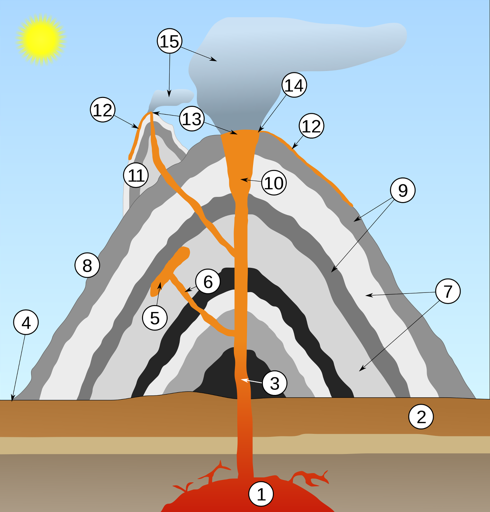

Baseline caption: A detailed diagram of a volcano, showcasing its internal structure and external features, including magma movement, volcanic activity, and surrounding geological layers.


In [34]:
# Inspect the architecture of Cosmos Reason 2 and run a baseline caption.
from transformers import AutoConfig, AutoModelForImageTextToText, AutoProcessor
from modelopt.torch.utils.plugins.vlm import (
    VLM_TEXT_TO_CAUSAL_MODEL_TYPE, _vlm_text_to_causal_model_type,
    is_vlm_checkpoint, resolve_vlm_lm_path,
)
from IPython.display import display
from PIL import Image
import requests, torch

cfg = AutoConfig.from_pretrained(COSMOS_PATH, trust_remote_code=True)
tc  = cfg.text_config

vlm = AutoModelForImageTextToText.from_pretrained(
    COSMOS_PATH, dtype=torch.bfloat16, device_map="auto", trust_remote_code=True
)
processor = AutoProcessor.from_pretrained(COSMOS_PATH, trust_remote_code=True)

# resolve_vlm_lm_path returns a dotted path like "model.language_model" — the same one
# the prune/distill scripts use to extract / reinsert the LM tower.
lm_path = resolve_vlm_lm_path(vlm)
lm = vlm
for part in lm_path.split("."):
    lm = getattr(lm, part)

total_b = sum(p.numel() for p in vlm.parameters()) / 1e9
lm_b    = sum(p.numel() for p in lm.parameters()) / 1e9
print(f"Total VLM params:               {total_b:.2f} B")
print(f"  Language tower ({lm_path}):  {lm_b:.2f} B")
print(f"  Vision + projector + heads:   {total_b - lm_b:.2f} B")
print()
print(f"architectures:           {cfg.architectures}")
print(f"text_config.model_type:  {tc.model_type}")
print(f"num_hidden_layers:       {tc.num_hidden_layers}")
print(f"hidden_size:             {tc.hidden_size}")
print(f"num_attention_heads:     {tc.num_attention_heads}")
print(f"num_key_value_heads:     {tc.num_key_value_heads}")
print(f"intermediate_size:       {tc.intermediate_size}")

# Baseline caption — same image/prompt as the post-prune check in §5.2 so you can
# eyeball the two captions side by side.
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/ai2d-demo.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
preview = image.copy(); preview.thumbnail((512, 512)); display(preview)

messages = [{"role": "user", "content": [
    {"type": "image", "image": image},
    {"type": "text", "text": "Describe the image in one short sentence."},
]}]
inputs = processor.apply_chat_template(
    messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt"
).to(vlm.device)
out = vlm.generate(**inputs, max_new_tokens=64, do_sample=False)
print("Baseline caption:", processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0])

In [35]:
# Empty the memory to proceed
import gc; del vlm; gc.collect(); torch.cuda.empty_cache()

---
## 5.2 Prune via Neural Architecture Search

We use the same [`prune_minitron.py`](../prune_minitron.py) script as notebook 01, but with a **NAS target** (`--prune_target_params 1.4e9`) instead of `--prune_export_config`. NAS enumerates candidate shapes by varying number of layers, attention heads, KV groups and FFN hidden size; ranks them against the size budget; scores the top-K on a lightweight benchmark; and exports the highest-scoring shape. For a reasoning model with non-obvious quality/size trade-offs that's the right default.

> ⚠️ `--hparams_to_skip hidden_size` is **mandatory** here. Without it NAS will happily pick a smaller `hidden_size` to hit the budget, and the reinsertion step will refuse to splice the smaller LM back into the original vision projector (`ValueError` in `reinsert_pruned_lm_into_vlm`). If you intentionally want a smaller hidden_size, drop the flag and plan on retraining the projector separately.

The Cosmos Reason 2 LM tower is ~1.7 B parameters (the remaining ~0.3 B in the 2 B VLM is the vision encoder + projector, which the prune script does not touch). Targeting 1.4 B is a **15 % cut on the LM tower** — i.e. the full VLM shrinks 2.0 B → ~1.7 B. Small enough that distillation (§3) should fully recover quality on a single 24 h node. Push the LM target to 1.2 B / 1.0 B in a follow-up once the 15 % recipe is dialled in.

In [19]:
PRUNED_PATH = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-pruned-NAS-1.5B"

!torchrun --nproc_per_node 1 ../prune_minitron.py \
    --pp_size 1 \
    --hf_model_name_or_path {COSMOS_PATH} \
    --prune_target_params 1.5e9 \
    --hparams_to_skip hidden_size \
    --top_k 20 \
    --calib_dataset_name wikitext \
    --calib_num_samples 512 \
    --output_hf_path {PRUNED_PATH}

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)/opt/venv/lib/python3.12/site-packages/comet_ml/error_tracking/api.py:51: UserWarning: We won't be continuing development on SDK 3.0. Please use the last stable version of the SDK to get access to the newest features and fixes. See https://github.com/getsentry/sentry-python/discu

In [ ]:
PRUNED_PATH = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-pruned-depth"
COSMOS_PATH = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-2B"

!torchrun --nproc_per_node 1 ../prune_minitron.py \
    --pp_size 1 \
    --hf_model_name_or_path "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-2B" \
    --prune_export_config '{"num_layers": 26}' \
    --calib_dataset_name wikitext \
    --calib_num_samples 512 \
    --output_hf_path {PRUNED_PATH}

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)/workspace/user_homes/lmikaelyan/Model-Optimizer/modelopt/torch/__init__.py:55: UserWarning: transformers>=5.0 support is experimental. Unified Hugging Face checkpoint export for quantized checkpoints may not work for some models yet.
  _warnings.warn(
/opt/Megatron-Bridge/3rdpar

In [ ]:
# Verify NAS-selected shape, confirm hidden_size is locked, and check the VLM still captions.
from transformers import AutoModelForImageTextToText, AutoProcessor
from modelopt.torch.utils.plugins.vlm import resolve_vlm_lm_path
from IPython.display import display
from PIL import Image
import requests, torch

pruned = AutoModelForImageTextToText.from_pretrained(
    PRUNED_PATH, dtype=torch.bfloat16, device_map="auto", trust_remote_code=True
)
processor = AutoProcessor.from_pretrained(PRUNED_PATH, trust_remote_code=True)
tc = pruned.config.text_config

lm_path = resolve_vlm_lm_path(pruned)
lm = pruned
for part in lm_path.split("."):
    lm = getattr(lm, part)
total_b = sum(p.numel() for p in pruned.parameters()) / 1e9
lm_b    = sum(p.numel() for p in lm.parameters()) / 1e9

print(f"Total VLM params:              {total_b:.2f} B")
print(f"  Language tower ({lm_path}): {lm_b:.2f} B  (pruned)")
print(f"  Vision + projector + heads:  {total_b - lm_b:.2f} B  (unchanged)")
print()
print(f"num_hidden_layers:   {tc.num_hidden_layers}  (NAS picked)")
print(f"num_attention_heads: {tc.num_attention_heads}  (NAS picked)")
print(f"num_key_value_heads: {tc.num_key_value_heads}  (NAS picked)")
print(f"intermediate_size:   {tc.intermediate_size}  (NAS picked)")
print(f"hidden_size:         {tc.hidden_size}  # locked at original")

url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/ai2d-demo.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
preview = image.copy(); preview.thumbnail((512, 512)); display(preview)

messages = [{"role": "user", "content": [
    {"type": "image", "image": image},
    {"type": "text", "text": "Describe the image in one short sentence."},
]}]
inputs = processor.apply_chat_template(
    messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt"
).to(pruned.device)
out = pruned.generate(**inputs, max_new_tokens=64, do_sample=False)
print("Caption:", processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0])

import gc; del pruned; gc.collect(); torch.cuda.empty_cache()

OSError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/workspace/user_homes/lmikaelyan/Cosmos-Reason2-pruned-depth'. Use `repo_type` argument if needed.

---
## 5.3 Distill

Text-only knowledge distillation from the unpruned Cosmos Reason 2 (teacher) into the pruned VLM (student), via [`distill.py`](../distill.py). The wrapper extracts both LM towers, runs `kd_loss` distillation on text tokens, then reinserts the distilled student LM back into the original VLM container.

**Cosmos Reason 2 is a reasoning VLM**, so the distillation corpus should preserve reasoning. We blend three Nemotron sources at sampling weights `0.5 / 0.3 / 0.2`:

| Dataset (HF) | Subset | Weight | Why |
|---|---|---:|---|
| `nvidia/Nemotron-Pretraining-Dataset-sample` | `Nemotron-CC-High-Quality-Synthetic` | 0.5 | General high-quality synthetic text — keeps the base language capability healthy. |
| `nvidia/Nemotron-Pretraining-SFT-v1` | `Nemotron-SFT-Math` | 0.3 | Chain-of-thought math reasoning. |
| `nvidia/Nemotron-Pretraining-SFT-v1` | `Nemotron-SFT-Code` | 0.2 | Chain-of-thought code reasoning. |

Tokenise each separately so they end up as **three distinct `.bin`/`.idx` prefixes**, then pass them to `distill.py` via `--data_paths <w> <prefix> <w> <prefix> <w> <prefix>`. All three are pretraining-style raw-text corpora (`text` key) → use `--append_eod`. See [`../dataset/MEGATRON_DATA_PREP.md`](../../dataset/MEGATRON_DATA_PREP.md) for chat-formatted alternatives.

In [21]:
import os, json
from itertools import islice
from datasets import load_dataset

RAW_DIR       = "/workspace/user_homes/lmikaelyan/distill_data_cosmos/raw"
TOKENIZED_DIR = "/workspace/user_homes/lmikaelyan/distill_data_cosmos/tokenized_cosmos"
os.makedirs(RAW_DIR, exist_ok=True)

# Streaming mode pulls parquet shards on demand, so disk usage tracks MAX_SAMPLES, not
# the source size. At gbs=512, seq=4096, 5 k iters consume ~10 B tokens; with 3 shards
# averaging ~500-1000 tokens/doc the 2 M-per-shard cap below leaves enough variety
# that the schedule does not loop. Drop back to 200_000 for a smoke run.
MAX_SAMPLES = 2_000_000

# Each tuple: (hf_dataset, hf_subset, output_jsonl_stem, sampling_weight).
SOURCES = [
    ("nvidia/Nemotron-Pretraining-Dataset-sample", "Nemotron-CC-High-Quality-Synthetic", "nemotron_cc",  0.5),
    ("nvidia/Nemotron-Pretraining-SFT-v1",         "Nemotron-SFT-MATH",                  "nemotron_math", 0.3),
    ("nvidia/Nemotron-Pretraining-SFT-v1",         "Nemotron-SFT-Code",                  "nemotron_code", 0.2),
]

for hf, subset, stem, _ in SOURCES:
    jsonl_path = f"{RAW_DIR}/{stem}.jsonl"
    if os.path.exists(jsonl_path) and os.path.getsize(jsonl_path) > 0:
        print(f"  {stem:<14} (cached) → {jsonl_path}")
        continue
    print(f"  {stem:<14} streaming up to {MAX_SAMPLES:,} docs from {hf}::{subset}...")
    ds = load_dataset(hf, subset, split="train", streaming=True)
    n = 0
    with open(jsonl_path, "w") as f:
        for row in islice(ds, MAX_SAMPLES):
            text = row.get("text", "")
            if not text or not text.strip():
                continue
            f.write(json.dumps({"text": text}) + "\n")
            n += 1
            if n % 10_000 == 0:
                print(f"    ... wrote {n:,}")
    print(f"  {stem:<14} {n:>7} docs → {jsonl_path}")

  nemotron_cc    (cached) → /workspace/user_homes/lmikaelyan/distill_data_cosmos/raw/nemotron_cc.jsonl
  nemotron_math  (cached) → /workspace/user_homes/lmikaelyan/distill_data_cosmos/raw/nemotron_math.jsonl
  nemotron_code  (cached) → /workspace/user_homes/lmikaelyan/distill_data_cosmos/raw/nemotron_code.jsonl


In [ ]:
# Tokenise all three JSONLs in one shot. megatron_preprocess_data with multiple
# --jsonl_paths produces one .bin/.idx per input, so we get three separately-weightable
# prefixes that we'll plumb into distill.py below.
PRUNED_PATH = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-pruned-NAS-1.5B"
TOKENIZED_DIR = "/workspace/user_homes/lmikaelyan/distill_data_cosmos/tokenized_cosmos-2"

!python -m modelopt.torch.utils.plugins.megatron_preprocess_data \
    --jsonl_paths \
        /workspace/user_homes/lmikaelyan/distill_data_cosmos/raw/nemotron_cc.jsonl \
        /workspace/user_homes/lmikaelyan/distill_data_cosmos/raw/nemotron_math.jsonl \
        /workspace/user_homes/lmikaelyan/distill_data_cosmos/raw/nemotron_code.jsonl \
    --json_keys text \
    --tokenizer {PRUNED_PATH} \
    --output_dir {TOKENIZED_DIR} \
    --workers 8 \
    --append_eod

!ls {TOKENIZED_DIR}

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)/opt/venv/lib/python3.12/site-packages/comet_ml/error_tracking/api.py:51: UserWarning: We won't be continuing development on SDK 3.0. Please use the last stable version of the SDK to get access to the newest features and fixes. See https://github.com/getsentry/sentry-python/discussions/4955
  sentry_sdk.init(
/workspace/user_homes/lmikaelyan/Model-Optimizer/modelopt/torch/__init__.py:55: UserWarning: transformers>=5.0 support is experimental. Unified Hugging Face checkpoint export for quantized checkpoints may not work for some models yet.
  _warnings.warn(
<frozen runpy>:128: RuntimeWarnin

In [22]:
PRUNED_PATH = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-pruned-NAS-1.5B"
TOKENIZED_DIR = "/workspace/user_homes/lmikaelyan/distill_data_cosmos/tokenized_cosmos-2"
DISTILL_WORK_DIR = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-distill-work"

In [29]:
DISTILLED_PATH = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-distilled"
# Sampling weights from §5.3 — must sum to 1.0; distill.py mixes them per training step.
DATA_PATHS = (
    f"0.1 {TOKENIZED_DIR}/nemotron_cc_text "
    f"0.6 {TOKENIZED_DIR}/nemotron_math_text "
    f"0.5 {TOKENIZED_DIR}/nemotron_code_text"
)

!torchrun --nproc_per_node 4 ../distill.py \
    --tp_size 1 \
    --student_hf_path {PRUNED_PATH} \
    --teacher_hf_path {COSMOS_PATH} \
    --data_paths {DATA_PATHS} \
    --seq_length 2048 --mbs 4 --gbs 1024 \
    --train_iters 100 \
    --lr 1e-4 --min_lr 1e-5 --lr_warmup_iters 40 \
    --eval_interval 100 --eval_iters 16 --log_interval 1 \
    --output_dir {DISTILL_WORK_DIR} \
    --hf_export_path {DISTILLED_PATH} \
    --student_hf_model {PRUNED_PATH} \
    --trust_remote_code

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr/local/lib/python3.12/dist-packages/torch/cud

In [17]:
!ls "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-distilled"

chat_template.jinja	model.safetensors      tokenizer_config.json
config.json		processor_config.json
generation_config.json	tokenizer.json


Loading weights: 100%|██████████| 625/625 [00:03<00:00, 201.73it/s]


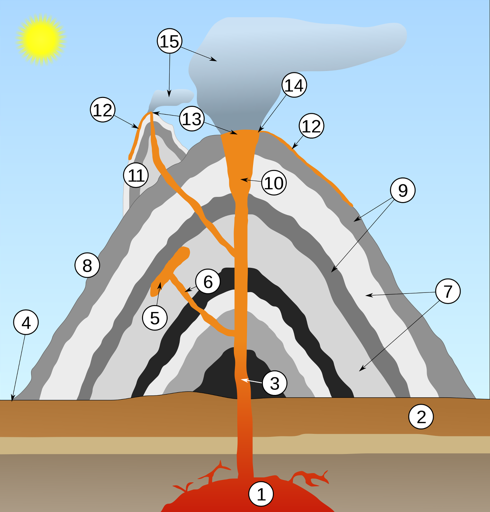

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Caption: The 1000

```

```

```

The 1000

```

The 1000

```

The 1000

```

```

```

```

```

```



In [18]:
# Sanity: distilled VLM still loads as a multimodal model and produces a coherent caption.
from transformers import AutoModelForImageTextToText, AutoProcessor
from IPython.display import display
from PIL import Image
import requests, torch

vlm = AutoModelForImageTextToText.from_pretrained(
    DISTILLED_PATH, dtype=torch.bfloat16, device_map="auto", trust_remote_code=True
)
processor = AutoProcessor.from_pretrained(DISTILLED_PATH, trust_remote_code=True)

url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/ai2d-demo.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
preview = image.copy(); preview.thumbnail((512, 512)); display(preview)

messages = [{"role": "user", "content": [
    {"type": "image", "image": image},
    {"type": "text", "text": "Describe the image in one short sentence."},
]}]
inputs = processor.apply_chat_template(
    messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt"
).to(vlm.device)
out = vlm.generate(**inputs, max_new_tokens=64, do_sample=False)
print("Caption:", processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0])

import gc; del vlm; gc.collect(); torch.cuda.empty_cache()

---
## 5.4 Quantize to FP8

Post-training FP8 quantization via [`../../llm_ptq/hf_ptq.py`](../../llm_ptq/hf_ptq.py). `--calib_with_images` builds the calibration set from image-text pairs so activation ranges in the projector → LM interface reflect real multimodal traffic — important for a VLM whose forward pass mixes visual and text tokens. NVFP4 is available with `--qformat nvfp4` on Blackwell.

FP8 on a reasoning VLM typically lands within 1 absolute point of BF16 on MathVista, so the recipe below is the same as notebooks 03/04. If you've selected a non-default best checkpoint in §5.3.1, change `DISTILLED_PATH` first.

In [ ]:
FP8_PATH = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-fp8"

!python ../../llm_ptq/hf_ptq.py \
    --pyt_ckpt_path {COSMOS_PATH} \
    --export_path   {FP8_PATH} \
    --qformat fp8 \
    --kv_cache_qformat none \
    --calib_with_images \
    --calib_size 512 \
    --trust_remote_code

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)/workspace/user_homes/lmikaelyan/Model-Optimizer/modelopt/torch/__init__.py:55: UserWarning: transformers>=5.0 support is experimental. Unified Hugging Face checkpoint export for quantized checkpoints may not work for some models yet.
  _warnings.warn(
ModelOpt save/restore enabled for `transformers` library.
ModelOpt save/restore enabled for `diffusers` library.
ModelOpt save/restore enabled for `peft` library.
Failed to get GPU memory info: Uninitialized. Stopping GPU memory monitor.
Initializing model from /workspace/user_homes/lmikaelyan/Cosmos-Reason2-2B
`torch_dtype` is deprecated! Us

---
## 5.5 Serve with vLLM

Start a vLLM OpenAI-compatible endpoint on the FP8 export. Run this in a separate terminal (or backgrounded), then return here to evaluate.

```bash
vllm serve /workspace/user_homes/lmikaelyan/Cosmos-Reason2-distilled-fp8 \
    --trust-remote-code --dtype bfloat16 \
    --mm-processor-kwargs '{"max_pixels": 2097152, "min_pixels": 262144, "max_num_frames": 1}'
```

The `--mm-processor-kwargs` cap is important for a reasoning VLM that routinely sees dense diagrams — without it a single high-resolution image can blow the per-request VRAM budget.

In [ ]:
# Poll vLLM until it's ready.
import requests, time
for _ in range(120):
    try:
        if requests.get("http://localhost:8000/health", timeout=2).status_code == 200:
            print("vLLM is ready"); break
    except requests.RequestException:
        pass
    time.sleep(5)
else:
    print("vLLM not reachable after 10 min — check the serve logs")

In [28]:
# Sanity-check the FP8 export through vLLM by captioning the same AI2D image used in
# §5.1 / §5.2. Coherent on-topic text → multimodal pipeline survived quantization.
# Garbled / repetitive / wrong-topic output → FP8 calibration or quant_method metadata
# is broken; do NOT proceed to §5.6 evaluation.
import requests

served_model = requests.get("http://localhost:8000/v1/models").json()["data"][0]["id"]
print(f"served: {served_model}")

resp = requests.post(
    "http://localhost:8000/v1/chat/completions",
    headers={"Authorization": "Bearer token-abc123"},
    timeout=120,
    json={
        "model": served_model,
        "messages": [{
            "role": "user",
            "content": [
                {"type": "image_url", "image_url": {
                    "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/ai2d-demo.jpg"
                }},
                {"type": "text", "text": "Describe the image in one short sentence."},
            ],
        }],
        "max_tokens": 64,
        "temperature": 0,
    },
).json()
print("FP8 caption:", resp["choices"][0]["message"]["content"])
print(f"tokens: prompt={resp['usage']['prompt_tokens']}, completion={resp['usage']['completion_tokens']}")

served: /workspace/user_homes/lmikaelyan/Cosmos-Reason2-fp8
FP8 caption: Numerous arrows point to various parts of a volcano, including magma pathways, volcanic eruptions, and surrounding geological layers.
tokens: prompt=2042, completion=25


---
## 5.6 Evaluate — 4-way comparison across 3 benchmark families

Goal: show that the compressed checkpoint (pruned + distilled + FP8) recovers almost all of the baseline BF16 quality. To make the recovery delta legible we evaluate **four checkpoints** on **three benchmark families** with a single eval driver:

| Variant | Path | What it tells us |
|---|---|---|
| **baseline** | `nvidia/Cosmos-Reason2-2B` (BF16) | Reference number to recover. |
| **pruned_only** | `{PRUNED_PATH}` (1.4 B LM, no distill) | Raw pruning damage — makes the distill delta visible. |
| **distilled_bf16** | `{DISTILLED_PATH}` (BF16) | What KD recovers before quantization. |
| **distilled_fp8** | `{FP8_PATH}` | Shippable artifact. |

| Benchmark | Why | Task names (lmms-eval) |
|---|---|---|
| **MathVista (testmini)** | Reasoning headline — Cosmos Reason 2's main specialisation. | `mathvista_testmini` |
| **PAI-Bench (BLINK proxies)** | Cosmos's intended Physical-AI domain. BLINK-Depth + BLINK-Spatial are the publicly reproducible parts of the PAI-Bench leaderboard. | `blink` (subtask filters in cell below) |
| **RealWorldQA** | General-purpose cross-check — guards against breaking non-reasoning behavior. | `realworldqa` |

We loop **vLLM-up → run all 3 benchmarks → vLLM-down** per variant. The §5.5 manual `vllm serve` command is wrapped in a helper that the driver calls. Expect ~30-40 min total per variant (≈ 2-3 h end-to-end on 1 H100).

> Stop the `vllm serve` you started in §5.5 before running this section — the driver manages its own vLLM lifecycle on the same port.

In [ ]:
# Discover which Cosmos-intended benchmarks the installed lmms-eval exposes.
# CR-Common / CR-Embodied (from the Physical AI Bench leaderboard) aren't always
# wired into stock lmms-eval; BLINK depth/spatial usually are.
import subprocess, re

raw = subprocess.run(
    ["python", "-m", "lmms_eval", "--tasks", "list"],
    capture_output=True, text=True, check=False,
).stdout
candidates = [
    line.strip() for line in raw.splitlines()
    if re.search(r"(blink|physical|cr_common|cr_embodied|pai_bench)", line, re.I)
]
print("Cosmos-relevant tasks available locally:")
for c in candidates:
    print(f"  {c}")

# Pick concrete task names. blink_val covers Depth + Spatial subtasks; use it as the
# PAI-Bench proxy if CR-Common / CR-Embodied aren't registered.
PAIBENCH_TASKS = [t for t in ["blink", "blink_val"] if any(t in c for c in candidates)]
if not PAIBENCH_TASKS:
    PAIBENCH_TASKS = ["blink"]  # default; eval driver will skip if unavailable
print(f"\nWill run PAI-Bench proxy tasks: {PAIBENCH_TASKS}")

In [ ]:
# 4-way × 3-benchmark driver. Brings vLLM up per variant, runs lmms-eval against all
# three benchmark families, tears vLLM down. Results land under EVAL_ROOT/<variant>/.
import os, subprocess, time, shlex, json, signal
import requests

EVAL_ROOT = "/workspace/user_homes/lmikaelyan/logs/cosmos-r2-recovery-eval"
os.makedirs(EVAL_ROOT, exist_ok=True)

VARIANTS = {
    "baseline":        COSMOS_PATH,          # unpruned Cosmos-Reason2-2B (BF16)
    "pruned_only":     PRUNED_PATH,          # NAS-pruned 1.4 B LM, no distill
    "distilled_bf16":  DISTILLED_PATH,       # pruned + distilled, BF16
    "distilled_fp8":   FP8_PATH,             # pruned + distilled + FP8 (final)
}
BENCHMARKS = {
    "mathvista":   ["mathvista_testmini"],
    "realworldqa": ["realworldqa"],
    "paibench":    PAIBENCH_TASKS,           # set in the discovery cell above
}
MM_KW = '{"max_pixels": 2097152, "min_pixels": 262144, "max_num_frames": 1}'


def serve_vllm(ckpt: str):
    """Start vLLM in the background, return the Popen handle."""
    cmd = (
        f"vllm serve {shlex.quote(ckpt)} "
        "--trust-remote-code --dtype bfloat16 "
        f"--mm-processor-kwargs {shlex.quote(MM_KW)}"
    )
    return subprocess.Popen(cmd, shell=True, preexec_fn=os.setsid)


def wait_ready(timeout_s: int = 600):
    for _ in range(timeout_s // 5):
        try:
            if requests.get("http://localhost:8000/v1/models", timeout=2).ok:
                return True
        except requests.RequestException:
            pass
        time.sleep(5)
    return False


def stop_vllm(p):
    try:
        os.killpg(os.getpgid(p.pid), signal.SIGTERM)
    except ProcessLookupError:
        pass
    p.wait(timeout=60)


def run_lmms_eval(ckpt: str, tasks: list[str], out_dir: str):
    if not tasks:
        return
    os.makedirs(out_dir, exist_ok=True)
    env = {**os.environ, "OPENAI_API_KEY": "token-abc123"}
    cmd = [
        "python", "-m", "lmms_eval",
        "--model", "openai",
        "--model_args", f"model={ckpt},base_url=http://localhost:8000/v1",
        "--tasks", ",".join(tasks),
        "--batch_size", "32",
        "--output_path", out_dir,
    ]
    subprocess.run(cmd, env=env, check=False)


for variant, ckpt in VARIANTS.items():
    print(f"\n{'='*60}\n>>> {variant}  ({ckpt})\n{'='*60}")
    proc = serve_vllm(ckpt)
    try:
        if not wait_ready():
            print(f"!! vLLM failed to come up for {variant}; skipping.")
            continue
        for bench_name, tasks in BENCHMARKS.items():
            out_dir = f"{EVAL_ROOT}/{variant}/{bench_name}"
            print(f"  -> {bench_name}: {tasks}")
            run_lmms_eval(ckpt, tasks, out_dir)
    finally:
        stop_vllm(proc)

print(f"\nAll variants done. Results under {EVAL_ROOT}/")

### Aggregate the comparison

Collect per-variant scores and render the recovery table. `% recovered` is

$$
\\text{{recovered}} = \\frac{{\\text{{variant}} - \\text{{pruned\\_only}}}}{{\\text{{baseline}} - \\text{{pruned\\_only}}}}
$$

so the pruned-only baseline anchors 0 % and the BF16 baseline anchors 100 %. The shippable artifact is `distilled_fp8`; we want its row to be ≥ 90 % recovered on every benchmark and within 2 absolute points of baseline on MathVista.

In [ ]:
# Walk EVAL_ROOT/<variant>/<bench>/ for lmms-eval result JSONs and render a table.
import os, json, glob

EVAL_ROOT = "/workspace/user_homes/lmikaelyan/logs/cosmos-r2-recovery-eval"
VARIANT_ORDER = ["baseline", "pruned_only", "distilled_bf16", "distilled_fp8"]
BENCH_KEYS = ["mathvista", "paibench", "realworldqa"]


def headline_metric(results_json: dict, task_substring: str) -> float | None:
    """Pull the first 'exact_match,*' or 'overall,*' metric for a task matching substring."""
    if "results" not in results_json:
        return None
    for task_name, metrics in results_json["results"].items():
        if task_substring not in task_name:
            continue
        for k, v in metrics.items():
            if (k.startswith("exact_match") or k.startswith("overall") or k.startswith("acc")) and not k.endswith("stderr") and isinstance(v, (int, float)):
                return float(v) * (100 if v <= 1 else 1)
    return None


def latest_result(variant: str, bench: str) -> dict | None:
    candidates = sorted(glob.glob(f"{EVAL_ROOT}/{variant}/{bench}/**/results*.json", recursive=True))
    if not candidates:
        return None
    with open(candidates[-1]) as f:
        return json.load(f)


scores: dict[str, dict[str, float | None]] = {v: {} for v in VARIANT_ORDER}
TASK_MATCH = {"mathvista": "mathvista", "paibench": "blink", "realworldqa": "realworldqa"}
for v in VARIANT_ORDER:
    for b in BENCH_KEYS:
        rj = latest_result(v, b)
        scores[v][b] = headline_metric(rj, TASK_MATCH[b]) if rj else None


def pct(num: float | None) -> str:
    return f"{num:5.1f}" if isinstance(num, float) else "  ?  "


print(f"{'variant':<18} | " + " | ".join(f"{b:>11}" for b in BENCH_KEYS))
print("-" * 70)
for v in VARIANT_ORDER:
    row = " | ".join(pct(scores[v][b]) for b in BENCH_KEYS)
    print(f"{v:<18} | {row}")

print("\n% recovered (vs. baseline, anchored at pruned_only=0%):")
print(f"{'variant':<18} | " + " | ".join(f"{b:>11}" for b in BENCH_KEYS))
print("-" * 70)
for v in VARIANT_ORDER:
    cells = []
    for b in BENCH_KEYS:
        base = scores["baseline"].get(b)
        prune = scores["pruned_only"].get(b)
        cur = scores[v].get(b)
        if None in (base, prune, cur) or base == prune:
            cells.append("   -   ")
            continue
        cells.append(f"{(cur - prune) / (base - prune) * 100:>9.1f}%")
    print(f"{v:<18} | " + " | ".join(cells))

---
## 5.7 Shutdown

Stop the vLLM server you started in §5.5.

In [ ]:
!pkill -f 'vllm serve' || true
!nvidia-smi --query-gpu=memory.used --format=csv,noheader

---
## Wrap-up

What just happened:

1. **Pruned** Cosmos Reason 2 on the LM tower from 1.7 B → ~1.4 B (15 % cut on the LM; full VLM 2.0 B → ~1.7 B since vision/projector is untouched) by NAS-searching over layer count, attention heads, KV groups and FFN width (hidden_size locked).
2. **Distilled** the pruned student against the unpruned teacher on a Nemotron CC + Math + Code blend — 5 000 iters TP=4 PP=2 on 8×H100, enough for full quality recovery on a 15 % cut.
3. **Quantized** the distilled VLM to FP8 with image-aware calibration; the resulting checkpoint serves directly with vLLM at ~2× the BF16 throughput on H100.
4. **Evaluated** all four variants (baseline / pruned-only / distilled / distilled+FP8) on MathVista, BLINK (PAI-Bench proxy), and RealWorldQA, and aggregated `% recovered` into a single table.

The full path uses the same scripts and helpers as notebooks 01-04 — the only differences for Cosmos Reason 2 are the model id, the choice of `--prune_target_params` over `--prune_export_config`, the Nemotron reasoning corpus over wikitext, and the 4-way comparison against three reasoning-aware benchmarks. Everything else (the VLM extract/reinsert wrappers, the `hidden_size` invariant guard, the FP8 calibration flow, the vLLM serve recipe) is reused without modification.

**Levers if MathVista falls short of the recovery target**, in order of expected impact:

1. Bump `--train_iters` 5000 → 8000 (still fits the 24 h budget).
2. Raise `--gbs` 512 → 1024 if memory allows (halves effective epochs per iter; helps when the corpus is large).
3. Tilt the corpus blend toward math: 0.5/0.3/0.2 → 0.4/0.4/0.2.
4. Add a short FP8 QAT pass after §4 (out of scope for this notebook; see `examples/llm_qat/`).